# Task 1 — Logistic Regression from scratch (archived working notebook)

This is the exploratory notebook behind Task 1: a plain mini-batch gradient
descent logistic regression and a learning-rate / epoch / batch-size grid.

**It is not the graded deliverable.** The submitted implementation, its tuning
(which adds L2, shuffling and a threshold search) and
`submissions/LogReg_Prediction.csv` all live in
`notebooks/TheHomiesML_Final_Submission.ipynb`, Section 1. This notebook writes
only to `results/archive/`, `figures/archive/` and `submissions/experiments/`
so that re-running it cannot overwrite a graded file.


In [9]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Works whether this notebook is opened from the repository root or archive/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
DATA_DIR   = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train_features.csv"
TEST_PATH  = DATA_DIR / "test_features.csv"
SPLIT_PATH = DATA_DIR / "splits" / "shared_validation_split.csv"

# This is an archived working notebook, so its output goes to the experiment
# folders. The graded Task 1 files are produced by the final submission notebook.
FIGURES_DIR     = PROJECT_ROOT / "figures" / "archive"
RESULTS_DIR     = PROJECT_ROOT / "results" / "archive"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions" / "experiments"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

print(TRAIN_PATH.exists(), TEST_PATH.exists(), SPLIT_PATH.exists())   # True True True

True True True


In [10]:
FEATURES = [c for c in pd.read_csv(TRAIN_PATH, nrows=0).columns
            if c not in ("id", "label")]
assert len(FEATURES) == 5000, f"Expected 5000 features, got {len(FEATURES)} — wrong file?"

dtypes = {c: np.float32 for c in FEATURES}
train_df = pd.read_csv(TRAIN_PATH, dtype=dtypes)
test_df  = pd.read_csv(TEST_PATH,  dtype=dtypes)

X_all  = train_df[FEATURES].to_numpy(np.float32)
y_all  = train_df["label"].to_numpy(np.float64)
X_test = test_df[FEATURES].to_numpy(np.float32)
test_ids = test_df["id"].copy()

del train_df, test_df
print(X_all.shape, y_all.shape, X_test.shape)   # (20000, 5000) (20000,) (6999, 5000)

(20000, 5000) (20000,) (6999, 5000)


In [11]:
split = pd.read_csv(SPLIT_PATH)
assert len(split) == len(X_all)

is_train = (split["split"] == "train").to_numpy()
X_train, y_train = X_all[is_train], y_all[is_train]
X_val, y_val = X_all[~is_train], y_all[~is_train]

print(X_train.shape, X_val.shape)
print(round(y_train.mean(), 4), round(y_val.mean(), 4))   # should match ≈0.6252

(16000, 5000) (4000, 5000)
0.6252 0.6252


In [12]:
def sigmoid(z):
    z = np.clip(z, -500, 500)          # prevents exp() overflow
    return 1.0 / (1.0 + np.exp(-z))


def loss(y, y_hat):
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)   # prevents log(0)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


def gradients(X, y, y_hat):
    m = X.shape[0]
    error = y_hat - y
    return (X.T @ error) / m, np.sum(error) / m


def train(X, y, bs, epochs, lr, verbose=False):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    losses = []
    n_batches = (m - 1) // bs + 1

    for epoch in range(epochs):
        for i in range(n_batches):
            xb = X[i * bs:(i + 1) * bs]
            yb = y[i * bs:(i + 1) * bs]
            y_hat = sigmoid(xb @ w + b)
            dw, db = gradients(xb, yb, y_hat)
            w -= lr * dw
            b -= lr * db
        losses.append(loss(y, sigmoid(X @ w + b)))
        if verbose and (epoch + 1) % 50 == 0:
            print(f"  epoch {epoch+1:4d}  loss {losses[-1]:.6f}")

    return w, b, losses


def predict(X, w, b):
    return (sigmoid(X @ w + b) >= 0.5).astype(int)


def macro_f1(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    scores = []
    for label in (0, 1):
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        denominator = 2 * tp + fp + fn
        scores.append(0.0 if denominator == 0 else 2 * tp / denominator)
    return float(np.mean(scores))

  epoch   50  loss 0.433585
  epoch  100  loss 0.388866
  epoch  150  loss 0.364155
  epoch  200  loss 0.347407
  epoch  250  loss 0.334917
  epoch  300  loss 0.325063
loss: 0.6441 -> 0.3251
val Macro F1: 0.734


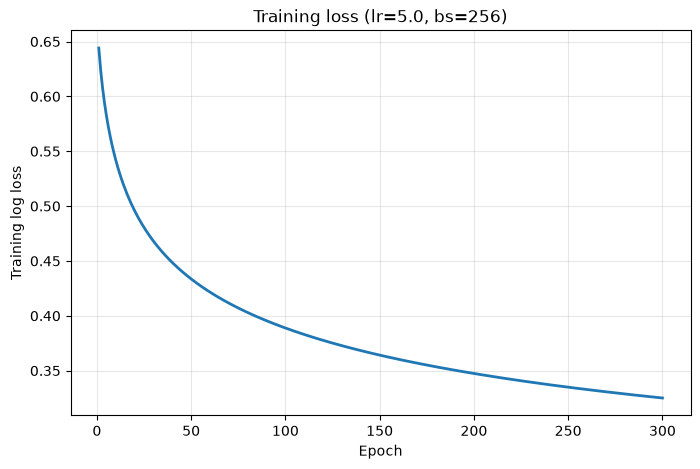

In [13]:
w, b, losses = train(X_train, y_train, bs=256, epochs=300, lr=5.0, verbose=True)

print("loss:", round(losses[0], 4), "->", round(losses[-1], 4))
print("val Macro F1:", round(macro_f1(y_val, predict(X_val, w, b)), 4))
assert losses[-1] < losses[0]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses) + 1), losses, linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Training log loss")
plt.title("Training loss (lr=5.0, bs=256)")
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / "logreg_training_loss.png", dpi=150)
plt.show()

In [14]:
results = []

for lr in [0.1, 0.01, 0.001]:
    for epochs in [100, 300, 500]:
        for bs in [64, 256]:
            t0 = time.time()
            w, b, hist = train(X_train, y_train, bs, epochs, lr)
            preds = predict(X_val, w, b)
            score = macro_f1(y_val, preds)
            results.append({
                "learning_rate": lr, "epochs": epochs, "batch_size": bs,
                "final_train_loss": hist[-1], "val_macro_f1": score,
                "pred_class1_rate": float(preds.mean()),
                "runtime_s": round(time.time() - t0, 1),
            })
            print(f"lr={lr:<7} ep={epochs:<4} bs={bs:<4} -> F1 {score:.4f} ({time.time()-t0:.0f}s)")

lr=0.1     ep=100  bs=64   -> F1 0.6132 (5s)
lr=0.1     ep=100  bs=256  -> F1 0.4032 (6s)
lr=0.1     ep=300  bs=64   -> F1 0.6971 (16s)
lr=0.1     ep=300  bs=256  -> F1 0.5646 (19s)
lr=0.1     ep=500  bs=64   -> F1 0.7192 (28s)
lr=0.1     ep=500  bs=256  -> F1 0.6311 (30s)
lr=0.01    ep=100  bs=64   -> F1 0.3847 (5s)
lr=0.01    ep=100  bs=256  -> F1 0.3847 (6s)
lr=0.01    ep=300  bs=64   -> F1 0.4194 (16s)
lr=0.01    ep=300  bs=256  -> F1 0.3847 (19s)
lr=0.01    ep=500  bs=64   -> F1 0.4937 (27s)
lr=0.01    ep=500  bs=256  -> F1 0.3847 (29s)
lr=0.001   ep=100  bs=64   -> F1 0.3847 (5s)
lr=0.001   ep=100  bs=256  -> F1 0.3847 (6s)
lr=0.001   ep=300  bs=64   -> F1 0.3847 (16s)
lr=0.001   ep=300  bs=256  -> F1 0.3847 (17s)
lr=0.001   ep=500  bs=64   -> F1 0.3847 (26s)
lr=0.001   ep=500  bs=256  -> F1 0.3847 (29s)


In [15]:
print("always 1:", round(macro_f1(y_val, np.ones_like(y_val, dtype=int)), 4))
print("always 0:", round(macro_f1(y_val, np.zeros_like(y_val, dtype=int)), 4))

always 1: 0.3847
always 0: 0.2726


In [16]:
for lr in [1.0, 5.0, 10.0, 20.0, 50.0]:
    for bs in [64, 256]:
        t0 = time.time()
        w, b, hist = train(X_train, y_train, bs, 300, lr)
        preds = predict(X_val, w, b)
        score = macro_f1(y_val, preds)
        results.append({
            "learning_rate": lr, "epochs": 300, "batch_size": bs,
            "final_train_loss": hist[-1], "val_macro_f1": score,
            "pred_class1_rate": float(preds.mean()),
            "runtime_s": round(time.time() - t0, 1),
        })
        print(f"lr={lr:<7} ep=300  bs={bs:<4} -> F1 {score:.4f} ({time.time()-t0:.0f}s)")

lr=1.0     ep=300  bs=64   -> F1 0.7352 (16s)
lr=1.0     ep=300  bs=256  -> F1 0.7326 (17s)
lr=5.0     ep=300  bs=64   -> F1 0.7209 (16s)
lr=5.0     ep=300  bs=256  -> F1 0.7340 (17s)
lr=10.0    ep=300  bs=64   -> F1 0.7134 (16s)
lr=10.0    ep=300  bs=256  -> F1 0.7243 (17s)
lr=20.0    ep=300  bs=64   -> F1 0.7045 (16s)
lr=20.0    ep=300  bs=256  -> F1 0.7139 (17s)
lr=50.0    ep=300  bs=64   -> F1 0.6862 (16s)
lr=50.0    ep=300  bs=256  -> F1 0.7214 (17s)


In [17]:
results_df = (pd.DataFrame(results)
              .sort_values("val_macro_f1", ascending=False)
              .reset_index(drop=True))

results_df.to_csv(RESULTS_DIR / "logreg_tuning_results_lr_grid.csv", index=False)
results_df.head(15)

,learning_rate,epochs,batch_size,final_train_loss,val_macro_f1,pred_class1_rate,runtime_s
0,1.0,300,64,0.337394,0.735212,0.66650,15.9
1,5.0,300,256,0.325063,0.733973,0.66575,17.4
2,1.0,300,256,0.421322,0.732580,0.70075,17.3
3,10.0,300,256,0.291157,0.724315,0.66475,17.3
4,50.0,300,256,0.328968,0.721396,0.59975,17.4
5,5.0,300,64,0.262447,0.720909,0.63800,15.9
6,0.1,500,64,0.448263,0.719212,0.72800,27.6
7,20.0,300,256,0.263492,0.713925,0.67375,17.4
8,10.0,300,64,0.242649,0.713365,0.61925,15.8
9,20.0,300,64,0.243160,0.704522,0.58025,15.9


In [18]:
best = results_df.iloc[0]
BEST_LR = float(best.learning_rate)
BEST_EPOCHS = int(best.epochs)
BEST_BS = int(best.batch_size)
print(BEST_LR, BEST_EPOCHS, BEST_BS, round(float(best.val_macro_f1), 4))

final_w, final_b, _ = train(X_all, y_all, BEST_BS, BEST_EPOCHS, BEST_LR, verbose=True)

1.0 300 64 0.7352
  epoch   50  loss 0.442972
  epoch  100  loss 0.402097
  epoch  150  loss 0.379826
  epoch  200  loss 0.364929
  epoch  250  loss 0.353959
  epoch  300  loss 0.345408


In [19]:
SUB_PATH = SUBMISSIONS_DIR / "LogReg_Prediction_LrGrid.csv"
test_preds = predict(X_test, final_w, final_b)

pd.DataFrame({"id": test_ids, "label": test_preds}).to_csv(SUB_PATH, index=False)
print(pd.Series(test_preds).value_counts().sort_index())

0    2012
1    4987
Name: count, dtype: int64


In [20]:
saved = pd.read_csv(SUB_PATH, dtype={"id": "string"})
expected = test_ids.astype("string").reset_index(drop=True)

assert saved.columns.tolist() == ["id", "label"]
assert len(saved) == 6999
assert saved["id"].tolist() == expected.tolist()
assert saved["label"].isnull().sum() == 0
assert set(saved["label"].unique()).issubset({0, 1})

print("verified — ready to upload")

verified — ready to upload
